In [33]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

In [34]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")
y_train = y_train.values.ravel()
y_test  = y_test.values.ravel()

  Training score : 0.9993
  Test score     : 0.8936


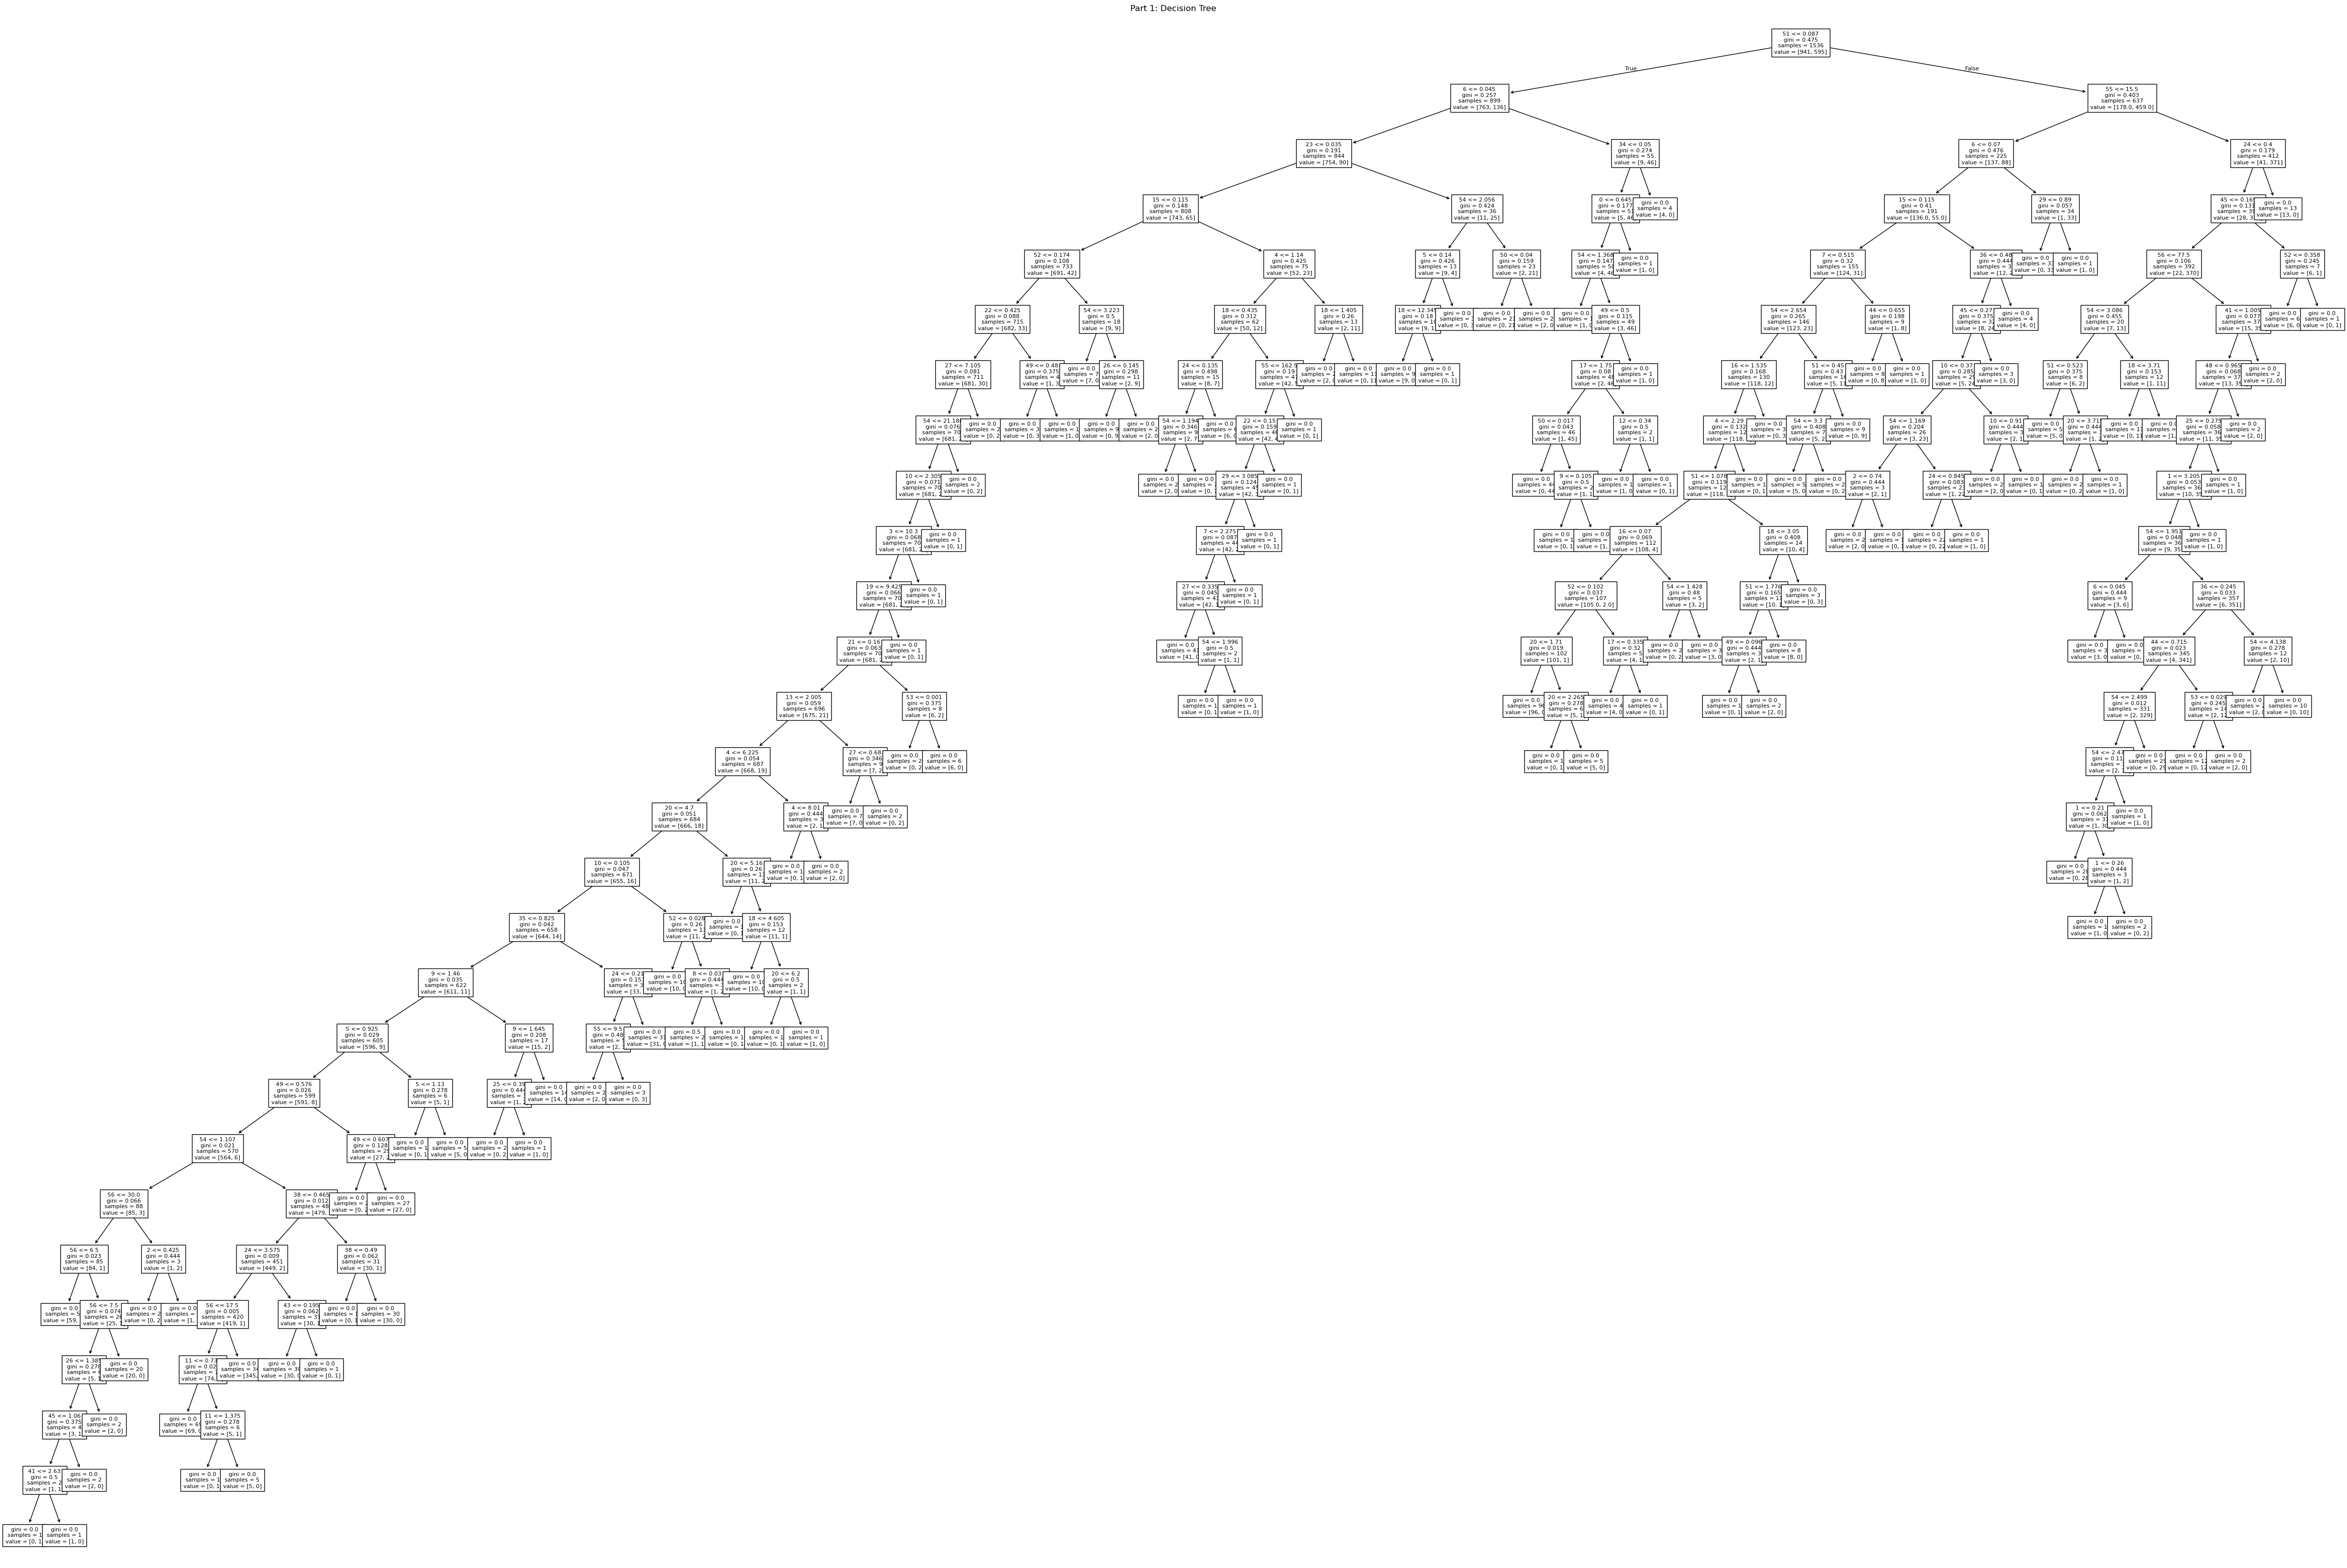

In [35]:
#problem 1
clf_full = tree.DecisionTreeClassifier()
clf_full.fit(X_train, y_train)
print(f"  Training score : {clf_full.score(X_train, y_train):.4f}")
print(f"  Test score     : {clf_full.score(X_test,  y_test):.4f}")

plt.figure(figsize=(60, 40))
tree.plot_tree(clf_full, fontsize=8, feature_names=X_train.columns.tolist())
plt.title("Part 1: Decision Tree")
plt.show()

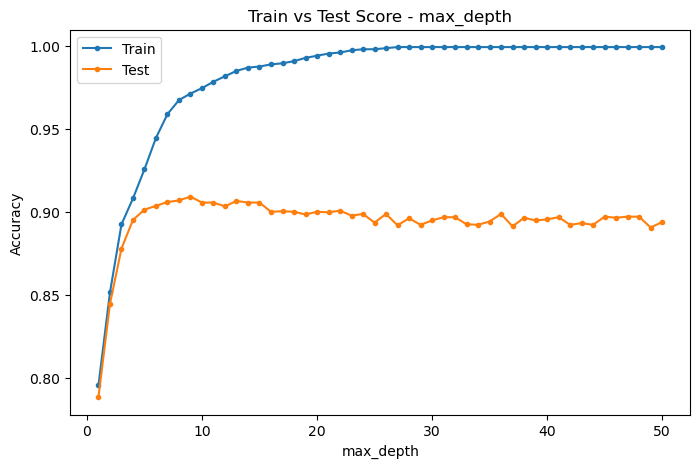

In [36]:
#problem 2a
max_depths      = range(1, 51)
train_scores_md = []
test_scores_md  = []

for d in max_depths:
    clf = tree.DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    train_scores_md.append(clf.score(X_train, y_train))
    test_scores_md.append(clf.score(X_test,  y_test))

plt.figure(figsize=(8, 5))
plt.plot(max_depths, train_scores_md, label="Train", marker='o', markersize=3)
plt.plot(max_depths, test_scores_md,  label="Test",  marker='o', markersize=3)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Score - max_depth")
plt.legend()
plt.show()

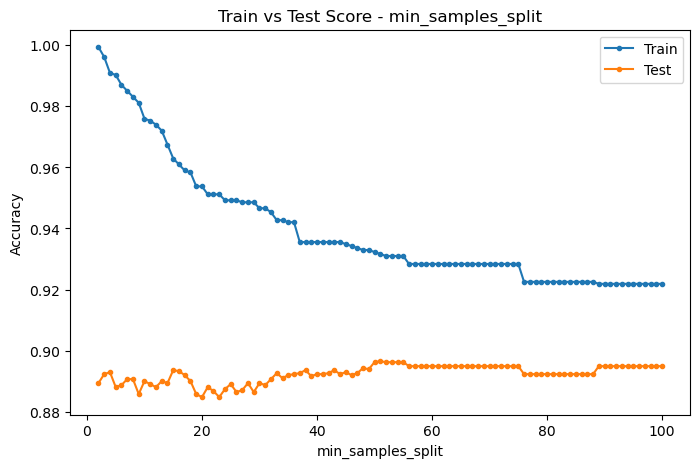

In [37]:
#problem 2b
min_splits       = range(2, 101)
train_scores_2 = []
test_scores_2  = []

for s in min_splits:
    clf = tree.DecisionTreeClassifier(min_samples_split=s)
    clf.fit(X_train, y_train)
    train_scores_2.append(clf.score(X_train, y_train))
    test_scores_2.append(clf.score(X_test,  y_test))

plt.figure(figsize=(8, 5))
plt.plot(min_splits, train_scores_2, label="Train", marker='o', markersize=3)
plt.plot(min_splits, test_scores_2,  label="Test",  marker='o', markersize=3)
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.title("Train vs Test Score - min_samples_split")
plt.legend()
plt.show()

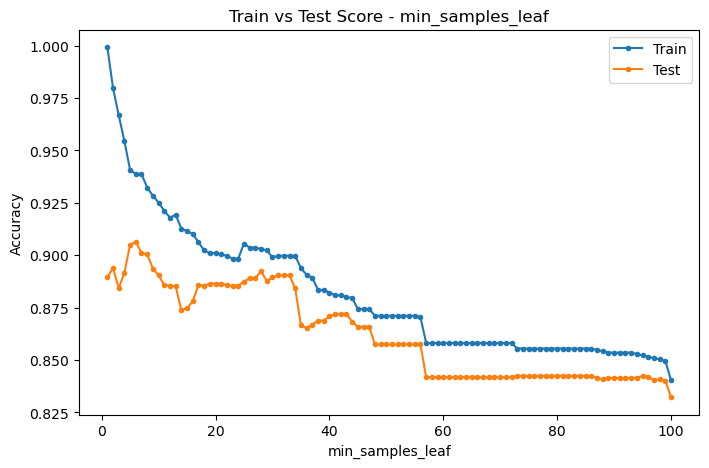

In [38]:
#problem 2c
min_leaves       = range(1, 101)
train_scores_3 = []
test_scores_3  = []

for l in min_leaves:
    clf = tree.DecisionTreeClassifier(min_samples_leaf=l)
    clf.fit(X_train, y_train)
    train_scores_3.append(clf.score(X_train, y_train))
    test_scores_3.append(clf.score(X_test,  y_test))

plt.figure(figsize=(8, 5))
plt.plot(min_leaves, train_scores_3, label="Train", marker='o', markersize=3)
plt.plot(min_leaves, test_scores_3,  label="Test",  marker='o', markersize=3)
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Train vs Test Score - min_samples_leaf")
plt.legend()
plt.show()

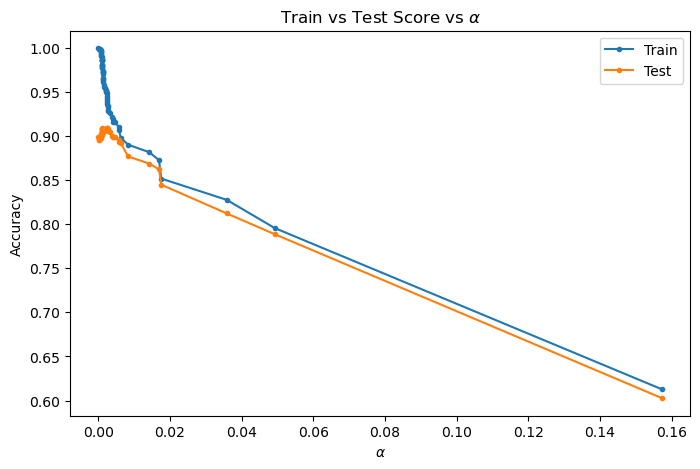

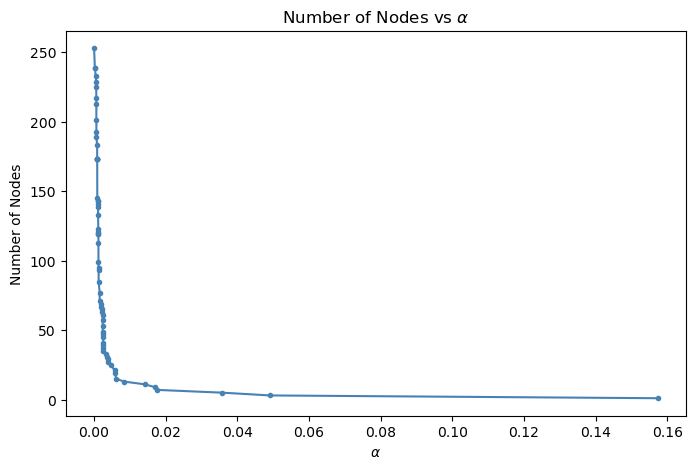

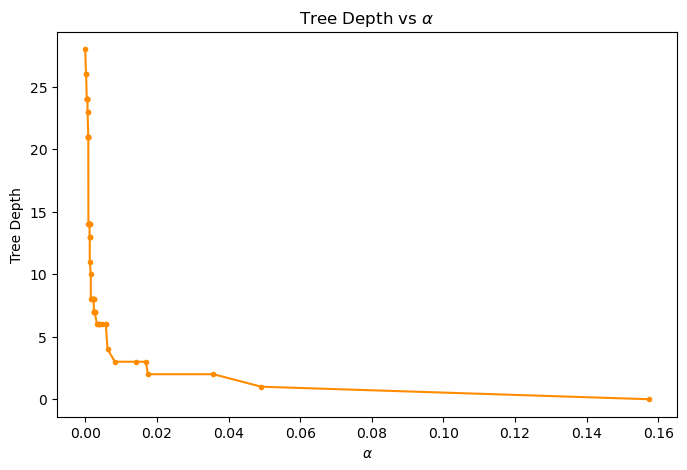

In [39]:
#problem 3
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas    
impurities = path.impurities 

clfs_ccp        = []
train_scores_ccp = []
test_scores_ccp  = []
n_nodes_ccp      = []
depths_ccp       = []

for alpha in alphas:
    clf = tree.DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    clfs_ccp.append(clf)
    train_scores_ccp.append(clf.score(X_train, y_train))
    test_scores_ccp.append(clf.score(X_test,  y_test))
    n_nodes_ccp.append(clf.tree_.node_count)
    depths_ccp.append(clf.get_depth())

plt.figure(figsize=(8, 5))
plt.plot(alphas, train_scores_ccp, label="Train", marker='o', markersize=3)
plt.plot(alphas, test_scores_ccp,  label="Test",  marker='o', markersize=3)
plt.xlabel(r"$\alpha$")
plt.ylabel("Accuracy")
plt.title(r"Train vs Test Score vs $\alpha$")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(alphas, n_nodes_ccp, marker='o', markersize=3, color='steelblue')
plt.xlabel(r"$\alpha$")
plt.ylabel("Number of Nodes")
plt.title(r"Number of Nodes vs $\alpha$")
plt.show()

# Plot 3: Tree depth vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, depths_ccp, marker='o', markersize=3, color='darkorange')
plt.xlabel(r"$\alpha$")
plt.ylabel("Tree Depth")
plt.title(r"Tree Depth vs $\alpha$")
plt.show()


In [40]:
#problem 4
forest_sizes  = range(10, 1001, 20)   
oob_scores    = []
test_scores_rf = []

for n in forest_sizes:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_features="sqrt",
        oob_score=True,
    )
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    test_scores_rf.append(rf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(forest_sizes, oob_scores,     label="OOB Score",  marker='o', markersize=2)
plt.plot(forest_sizes, test_scores_rf, label="Test Score", marker='o', markersize=2)
plt.xlabel("Number of Trees (Forest Size)")
plt.ylabel("Accuracy")
plt.title("OOB Score and Test Score vs Forest Size")
plt.legend()
plt.show()

print(f"  OOB Score  : {oob_scores[-1]:.4f}")
print(f"  Test Score : {test_scores_rf[-1]:.4f}")

/usr/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Due to some problems, I am unable to run with smaller steps in my pc without getting kernel stopped. But for smaller steps, the plot is similar